In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

### Parameters

In [2]:
DATA_FILE = "CellDNA.csv"
INDEX_FILE = "CellDNA_30rows_Indices.csv"

LEARNING_RATE = 1e-3
BATCH_SIZE = 8
NN_EPOCHS = 200
AE_EPOCHS = 50

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

### Helper Function

In [3]:
def load_data(data_file, index_file):
    """ Load and preprocess the CellDNA dataset for two-class classification.

    This function reads the full CellDNA dataset and the file containing the
    row indices used. Selecting the specified rows, separates the feature matrix 
    and target labels, and converts the target values into binary classes.

    Parameters
    ----------
    data_file : str
        Path to the CSV file containing the full CellDNA dataset.

    index_file : str
        Path to the CSV file containing the indices used to select
        the subset from CellDNA.

    Returns
    -------
    X : numpy.ndarray
        Feature matrix in float32.

    Y : numpy.ndarray
        Target array in binary.

    Notes
    -----
    """
    df = pd.read_csv(data_file, header=None)
    idx_df = pd.read_csv(index_file, header=None)

    indices = idx_df.values.flatten()
    indices = pd.to_numeric(indices, errors="coerce")
    indices = indices[~np.isnan(indices)].astype(int)

    # If indices are 1-based, convert to 0-based
    if indices.min() >= 1:
        indices = indices - 1

    selected_df = df.iloc[indices].copy()

    X = selected_df.iloc[:, :-1].values.astype(np.float32)
    Y_raw = selected_df.iloc[:, -1].values
    Y = (Y_raw != 0).astype(np.int64)

    return X, Y

In [4]:
def load_all_data(data_file):
    df = pd.read_csv(data_file, header=None)

    X = df.iloc[:, :-1].values.astype(np.float32)
    Y_raw = df.iloc[:, -1].values
    Y = (Y_raw != 0).astype(np.int64)

    return X, Y

### Regular NN

In [5]:
class RegularNN(nn.Module):
    """ Regular neural network.

    Architecture:
        X -> 10 -> 7 -> 4 -> 2 -> Y
    """
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 10),
            nn.ReLU(),

            nn.Linear(10, 7),
            nn.ReLU(),

            nn.Linear(7, 4),
            nn.ReLU(),

            nn.Linear(4, 2)
        )

    def forward(self, x):
        return self.net(x)

### AutoEncoder

In [6]:
class Autoencoder(nn.Module):
    """
    Single autoencoder.

    Architecture:
        input -> hidden_dim -> input
    """
    def __init__(self, input_dim, hidden_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

In [7]:
class AEClassifier(nn.Module):
    """ Classifier for AE stack network

    Architecture:
        4 -> 2
    """
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(4, 2)
        )

    def forward(self, x):
        return self.net(x)

In [8]:
class StackedAENN(nn.Module):
    """ Final stacked classifier after layer-wise training.

    Architecture:
        X -> 10 -> 7 -> 4 -> 2
    """
    def __init__(self, input_dim):
        super().__init__()

        self.encoder1 = nn.Sequential(
            nn.Linear(input_dim, 10),
            nn.ReLU()
        )

        self.encoder2 = nn.Sequential(
            nn.Linear(10, 7),
            nn.ReLU()
        )

        self.encoder3 = nn.Sequential(
            nn.Linear(7, 4),
            nn.ReLU()
        )

        self.classifier = nn.Linear(4, 2)

    def forward(self, x):
        x = self.encoder1(x)
        x = self.encoder2(x)
        x = self.encoder3(x)
        x = self.classifier(x)
        return x

### Training Function

In [9]:
def train(model, X, Y, epochs, batch_size, device):
    model.train()

    dataset = TensorDataset(X, Y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    for epoch in range(epochs):
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

In [10]:
def trainAE(model, X, epochs, batch_size, device):
    model.train()

    dataset = TensorDataset(X, X)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    for epoch in range(epochs):
        for xb, _ in loader:
            xb = xb.to(device)

            optimizer.zero_grad()
            recon = model(xb)
            loss = criterion(recon, xb)
            loss.backward()
            optimizer.step()

In [11]:
def evaluate(model, X, Y, title, device):
    model.eval()

    with torch.no_grad():
        logits = model(X.to(device))
        preds = torch.argmax(logits, dim=1).cpu().numpy()

    Y_true = Y.cpu().numpy()
    cm = confusion_matrix(Y_true, preds)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(title)
    plt.show()

In [12]:
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    X, Y = load_data(DATA_FILE, INDEX_FILE)
    
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    X = torch.tensor(X, dtype=torch.float32)
    Y = torch.tensor(Y, dtype=torch.long)

    input_dim = X.shape[1]

    print("\nTraining Regular Neural Network")
    nn_model = RegularNN(input_dim).to(device)
    train(nn_model, X, Y, NN_EPOCHS, BATCH_SIZE, device)

    print("\nTraining NN1: X -> 10 -> X")
    ae1 = Autoencoder(input_dim, 10).to(device)
    trainAE(ae1, X, AE_EPOCHS, BATCH_SIZE, device)

    with torch.no_grad():
        X1 = ae1.encoder(X.to(device)).cpu()

    print("\nTraining NN2: 10 -> 7 -> 10")
    ae2 = Autoencoder(10, 7).to(device)
    trainAE(ae2, X1, AE_EPOCHS, BATCH_SIZE, device)

    with torch.no_grad():
        X2 = ae2.encoder(X1.to(device)).cpu()

    print("\nTraining NN3: 7 -> 4 -> 7")
    ae3 = Autoencoder(7, 4).to(device)
    trainAE(ae3, X2, AE_EPOCHS, BATCH_SIZE, device)

    with torch.no_grad():
        X3 = ae3.encoder(X2.to(device)).cpu()

    print("\nTraining NN4: 4 -> 2 -> Y")
    last_clf = AEClassifier().to(device)
    train(last_clf, X3, Y, AE_EPOCHS, BATCH_SIZE, device)

    # =====================================================
    # 3) Build final stacked model
    # =====================================================
    print("\nBuilding Final Stacked Classifier")
    sae_model = StackedAENN(input_dim).to(device)

    # copy pretrained encoder weights
    sae_model.encoder1[0].weight.data = ae1.encoder[0].weight.data.clone()
    sae_model.encoder1[0].bias.data = ae1.encoder[0].bias.data.clone()

    sae_model.encoder2[0].weight.data = ae2.encoder[0].weight.data.clone()
    sae_model.encoder2[0].bias.data = ae2.encoder[0].bias.data.clone()

    sae_model.encoder3[0].weight.data = ae3.encoder[0].weight.data.clone()
    sae_model.encoder3[0].bias.data = ae3.encoder[0].bias.data.clone()

    sae_model.classifier.weight.data = last_clf.net[0].weight.data.clone()
    sae_model.classifier.bias.data = last_clf.net[0].bias.data.clone()

    train(sae_model, X, Y, AE_EPOCHS, BATCH_SIZE, device)

    return nn_model, sae_model, X, Y, scaler, device

In [13]:
if __name__ == "__main__":
    nn_model, sae_model, X, Y, scaler, device = main()

Using device: cuda

Training Regular Neural Network

Training NN1: X -> 10 -> X

Training NN2: 10 -> 7 -> 10

Training NN3: 7 -> 4 -> 7

Training NN4: 4 -> 2 -> Y

Building Final Stacked Classifier


### Visualization

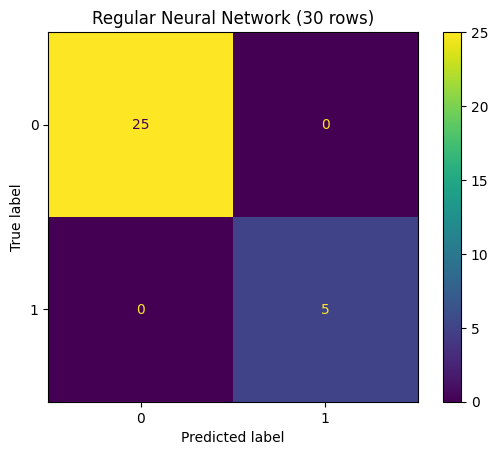

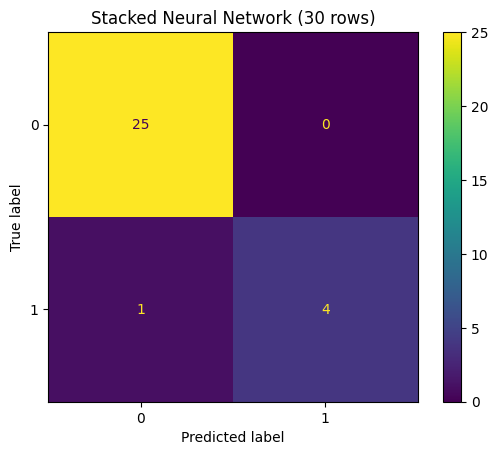

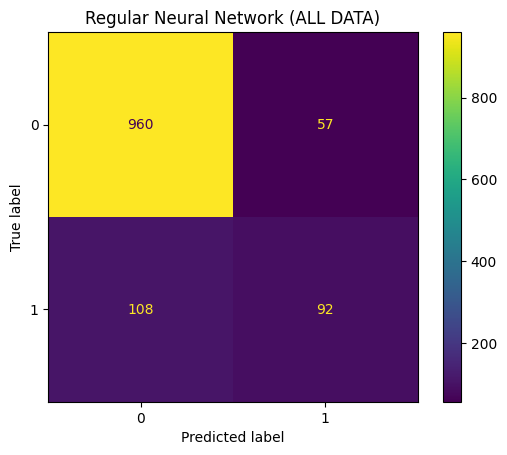

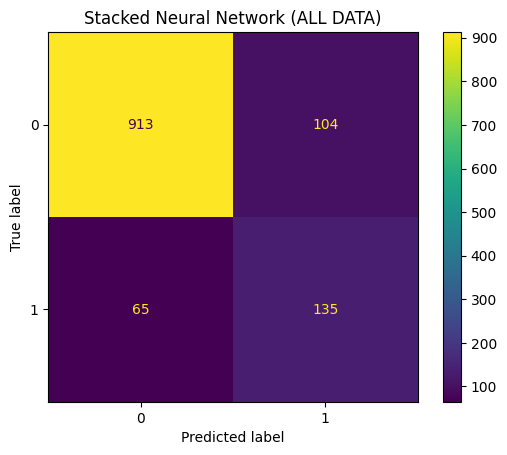

In [14]:
# Evaluation on 30 selected rows
evaluate(nn_model, X, Y, "Regular Neural Network (30 rows)", device)
evaluate(sae_model, X, Y, "Stacked Neural Network (30 rows)", device)

# Evaluation on all data
X_all, Y_all = load_all_data(DATA_FILE)
X_all = scaler.transform(X_all)

X_all = torch.tensor(X_all, dtype=torch.float32)
Y_all = torch.tensor(Y_all, dtype=torch.long)

evaluate(nn_model, X_all, Y_all, "Regular Neural Network (ALL DATA)", device)
evaluate(sae_model, X_all, Y_all, "Stacked Neural Network (ALL DATA)", device)